# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari Kaggle dimana saya menggunakan dataset **Indonesia Tourism Destination** yang menggabungkan tiga entitas data terstruktur untuk membangun sistem rekomendasi pariwisata berbasis segmentasi usia pengguna.
2. **Detail Dataset**:
   1. **user.xml**: Menyimpan profil demografi pengguna, meliputi User_Id, Location, dan Age.
   2. **tourism_rating.xml**: Catatan interaksi aktivitas pemberian rating objek wisata oleh pengguna, meliputi User_Id, Place_Id, dan Place_Rating.
   3. **tourism_with_id.xml**: Informasi katalog destinasi wisata di Indonesia, meliputi Place_Id, Place_Name, Category, City, Price, dan Rating.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
#Type your code here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
#Type your code here
df_user = pd.read_csv('user.csv')
df_rating = pd.read_csv('tourism_rating.csv')
df_tourism = pd.read_csv('tourism_with_id.csv')

df_merged = pd.merge(df_rating, df_tourism, on='Place_Id', how='inner')
df_main = pd.merge(df_merged, df_user, on='User_Id', how='inner')

print(f"Ukuran akhir data gabungan: {df_main.shape}")
df_main.head()

Ukuran akhir data gabungan: (10000, 17)


,User_Id,Place_Id,Place_Ratings,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Unnamed: 11,Unnamed: 12,Location,Age
0,1,179,3,Candi Ratu Boko,Situs Ratu Baka atau Candi Boko (Hanacaraka:ꦕꦤ...,Budaya,Yogyakarta,75000,4.6,90.0,"{'lat': -7.7705416, 'lng': 110.4894158}",-7.770542,110.489416,NaN,179,"Semarang, Jawa Tengah",20
1,1,344,2,Pantai Marina,"Pantai Marina (bahasa Jawa: ꦥꦱꦶꦱꦶꦂ​ꦩꦫꦶꦤ, trans...",Bahari,Semarang,3000,4.1,NaN,"{'lat': -6.948877, 'lng': 110.3893285}",-6.948877,110.389329,NaN,344,"Semarang, Jawa Tengah",20
2,1,5,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134,NaN,5,"Semarang, Jawa Tengah",20
3,1,373,3,Museum Kereta Ambarawa,Museum Kereta Api Ambarawa (bahasa Inggris: In...,Budaya,Semarang,10000,4.5,60.0,"{'lat': -7.264598899999997, 'lng': 110.4046017}",-7.264599,110.404602,NaN,373,"Semarang, Jawa Tengah",20
4,1,101,4,Kampung Wisata Sosro Menduran,Kampung wisata Sosromenduran merupakan kampung...,Budaya,Yogyakarta,0,4.0,NaN,"{'lat': -7.792189999999999, 'lng': 110.362151}",-7.792190,110.362151,NaN,101,"Semarang, Jawa Tengah",20


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

/tmp/ipykernel_1208/2062133616.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_main, y='Category', order=df_main['Category'].value_counts().index, palette='viridis', ax=axes[1])


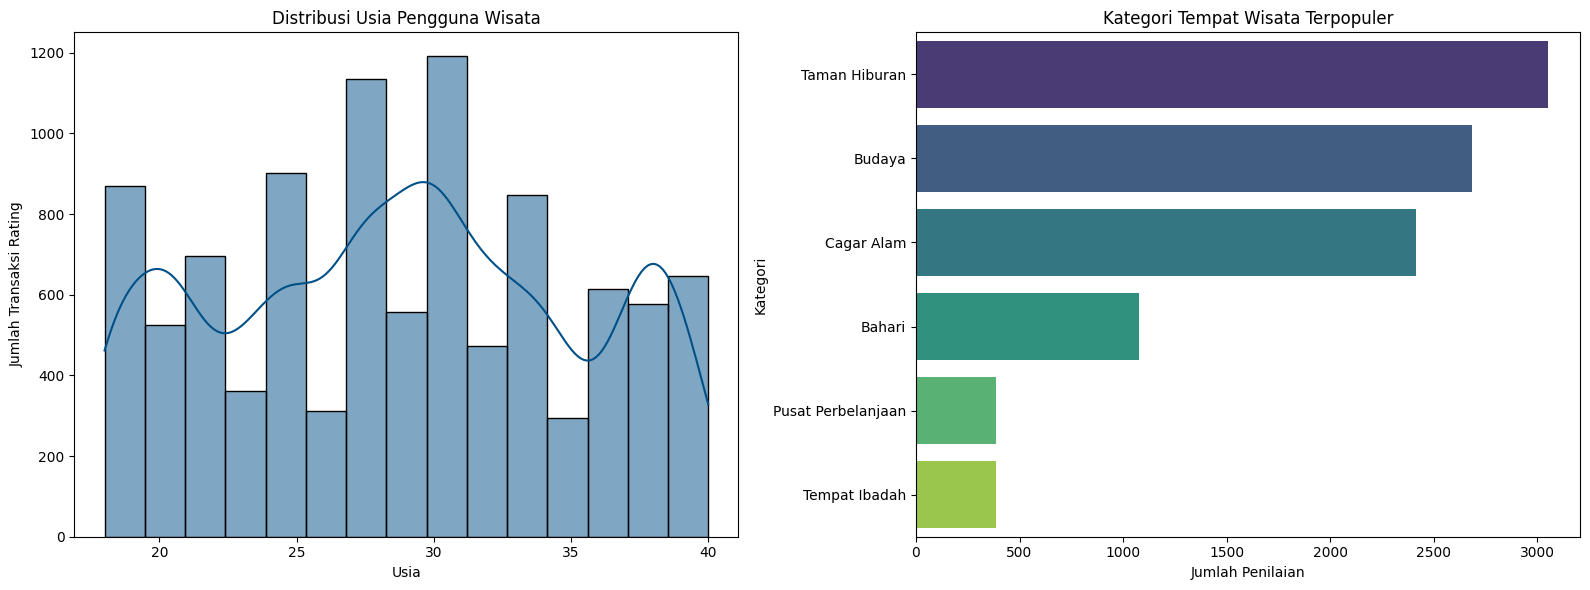

In [3]:
#Type your code here
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=df_main, x='Age', bins=15, kde=True, color='#005088', ax=axes[0])
axes[0].set_title('Distribusi Usia Pengguna Wisata')
axes[0].set_xlabel('Usia')
axes[0].set_ylabel('Jumlah Transaksi Rating')

sns.countplot(data=df_main, y='Category', order=df_main['Category'].value_counts().index, palette='viridis', ax=axes[1])
axes[1].set_title('Kategori Tempat Wisata Terpopuler')
axes[1].set_xlabel('Jumlah Penilaian')
axes[1].set_ylabel('Kategori')

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [6]:
# =====================================================================
# 1. ANALISIS DATA AWAL SEBELUM PREPROCESSING
# =====================================================================
total_awal = len(df_main)
missing_values = df_main.isnull().sum().sum()
duplikat_count = df_main.duplicated().sum()

print("=== ANALISIS DATA AWAL ===")
print(f"Total baris data sebelum preprocessing : {total_awal} baris")
print(f"Jumlah data yang kosong (Missing Value): {missing_values} data")
print(f"Jumlah data yang duplikat              : {duplikat_count} baris")
print("\nDetail data kosong per kolom:")
print(df_main.isnull().sum())
print("\n" + "="*50 + "\n")

# =====================================================================
# 2. PROSES DATA PREPROCESSING (PERBAIKAN)
# =====================================================================
# LINGKAH 1: Buang kolom sampah/tidak valid terlebih dahulu agar tidak merusak dropna
kolom_sampah = ['Unnamed: 11', 'Unnamed: 12', 'Coordinate', 'Time_Minutes']
df_drop_cols = df_main.drop(columns=kolom_sampah, errors='ignore')

# LANGKAH 2: Baru bersihkan missing value dan duplikat dari kolom yang tersisa
df_cleaned = df_drop_cols.dropna().drop_duplicates()

# LANGKAH 3: Binning Usia menjadi Kelompok Usia
age_bins = [0, 18, 30, 50, 100]
age_labels = ['Anak-anak', 'Remaja_DewasaMuda', 'Dewasa', 'Lansia']
df_cleaned['Age_Group'] = pd.cut(df_cleaned['Age'], bins=age_bins, labels=age_labels)

# LANGKAH 4: Label Encoding untuk kolom kategorikal
encoder = LabelEncoder()
categorical_cols = ['Category', 'City', 'Age_Group']
for col in categorical_cols:
    df_cleaned[f'{col}_Encoded'] = encoder.fit_transform(df_cleaned[col])

# LANGKAH 5: Normalisasi / Scaling Fitur Harga (MinMax Scaling)
df_cleaned['Price_Scaled'] = (df_cleaned['Price'] - df_cleaned['Price'].min()) / (df_cleaned['Price'].max() - df_cleaned['Price'].min())

# LANGKAH 6: Seleksi Fitur Akhir (Buang kolom teks asli yang sudah di-encode)
drop_text_cols = ['Place_Name', 'Description', 'Category', 'City', 'Location', 'Age', 'Age_Group']
df_final = df_cleaned.drop(columns=drop_text_cols, errors='ignore')

# LANGKAH 7: Menyimpan hasil data bersih ke dalam folder baru
import os
os.makedirs('namadataset_preprocessing', exist_ok=True)
df_final.to_csv('namadataset_preprocessing/tourism_preprocessed.csv', index=False)

# =====================================================================
# 3. SPESIFIKASI DATA SETELAH PREPROCESSING (HASIL AKHIR)
# =====================================================================
print("=== SPESIFIKASI DATA SETELAH PREPROCESSING ===")
print(f"Total baris data siap latih: {df_final.shape[0]} baris")
print(f"Total kolom data siap latih: {df_final.shape[1]} kolom")
print("\nDaftar kolom akhir beserta tipe datanya:")
print(df_final.dtypes)
print("\n--- 5 BARIS DATA TERATAS ---")
df_final.head()

=== ANALISIS DATA AWAL ===
Total baris data sebelum preprocessing : 10000 baris
Jumlah data yang kosong (Missing Value): 15372 data
Jumlah data yang duplikat              : 79 baris

Detail data kosong per kolom:
User_Id              0
Place_Id             0
Place_Ratings        0
Place_Name           0
Description          0
Category             0
City                 0
Price                0
Rating               0
Time_Minutes      5372
Coordinate           0
Lat                  0
Long                 0
Unnamed: 11      10000
Unnamed: 12          0
Location             0
Age                  0
dtype: int64


=== SPESIFIKASI DATA SETELAH PREPROCESSING ===
Total baris data siap latih: 9921 baris
Total kolom data siap latih: 11 kolom

Daftar kolom akhir beserta tipe datanya:
User_Id                int64
Place_Id               int64
Place_Ratings          int64
Price                  int64
Rating               float64
Lat                  float64
Long                 float64
Category_En

,User_Id,Place_Id,Place_Ratings,Price,Rating,Lat,Long,Category_Encoded,City_Encoded,Age_Group_Encoded,Price_Scaled
0,1,179,3,75000,4.6,-7.770542,110.489416,1,4,2,0.083333
1,1,344,2,3000,4.1,-6.948877,110.389329,0,2,2,0.003333
2,1,5,5,94000,4.5,-6.124190,106.839134,4,1,2,0.104444
3,1,373,3,10000,4.5,-7.264599,110.404602,1,2,2,0.011111
4,1,101,4,0,4.0,-7.792190,110.362151,1,4,2,0.000000
